In [1]:
##################### Plot Initial Conditions ######################
# The purpose of this script is to plot the initial conditions for
# the idealized Beaufort shelfbreak jet model. These will include
# vertical cross sections and surface things. 
#
# Notes:
# - This script heavily uses code written by Dylan Schlichting
#
#####################################################################

In [1]:
# Load in the packages
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import LogFormatterExponent
import warnings
import xarray as xr
import os
import xroms
from glob import glob
from joblib import Parallel, delayed
warnings.filterwarnings("ignore") #turns off annoying warnings

In [2]:
# Load in the initial conditions 
# 500 m case, all runs
ini_conds = xr.open_dataset('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/ini_ice_500_m.nc')

In [15]:
# Load in the grid
grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/grd_500_m.nc')

In [16]:
grid.x_rho

<xarray.DataArray 'x_rho' (eta_rho: 1002, xi_rho: 402)> Size: 3MB
[402804 values with dtype=float64]
Dimensions without coordinates: eta_rho, xi_rho

In [7]:
# Make coordinates for plotting
x_rho = grid.x_rho / 1000
x_u = grid.x_u / 1000
y_rho = grid.y_rho / 1000 
y_u = grid.y_u / 1000

In [44]:
ini_conds

<xarray.Dataset> Size: 699MB
Dimensions:             (s_rho: 40, eta_rho: 1002, xi_rho: 402, ocean_time: 1,
                         eta_u: 1002, xi_u: 401, eta_v: 1001, xi_v: 402)
Coordinates:
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * xi_rho              (xi_rho) int64 3kB 0 1 2 3 4 5 ... 397 398 399 400 401
  * eta_rho             (eta_rho) int64 8kB 0 1 2 3 4 ... 997 998 999 1000 1001
  * ocean_time          (ocean_time) timedelta64[ns] 8B 00:00:00
Dimensions without coordinates: eta_u, xi_u, eta_v, xi_v
Data variables: (12/22)
    temp                (s_rho, eta_rho, xi_rho) float64 129MB ...
    salt                (s_rho, eta_rho, xi_rho) float64 129MB ...
    u                   (ocean_time, s_rho, eta_u, xi_u) float64 129MB ...
    v                   (ocean_time, s_rho, eta_v, xi_v) float64 129MB ...
    zeta                (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ubar                (ocean_time, eta_u, xi_u) float64 3MB ...
    ...                  ...
    ice_sst             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Sxx             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Sxy             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Syy             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    Uice                (ocean_time, eta_u, xi_u) float64 3MB ...
    Vice                (ocean_time, eta_v, xi_v) float64 3MB ...
Attributes:
    type:         ROMS Ini file
    Description:  Initial conditions for ideal shelf
    Author:       Dylan Schlichting
    Created:      2025-12-29T14:52:59.098776

Text(0.5, 1.0, 'Along-Shore Velocity')

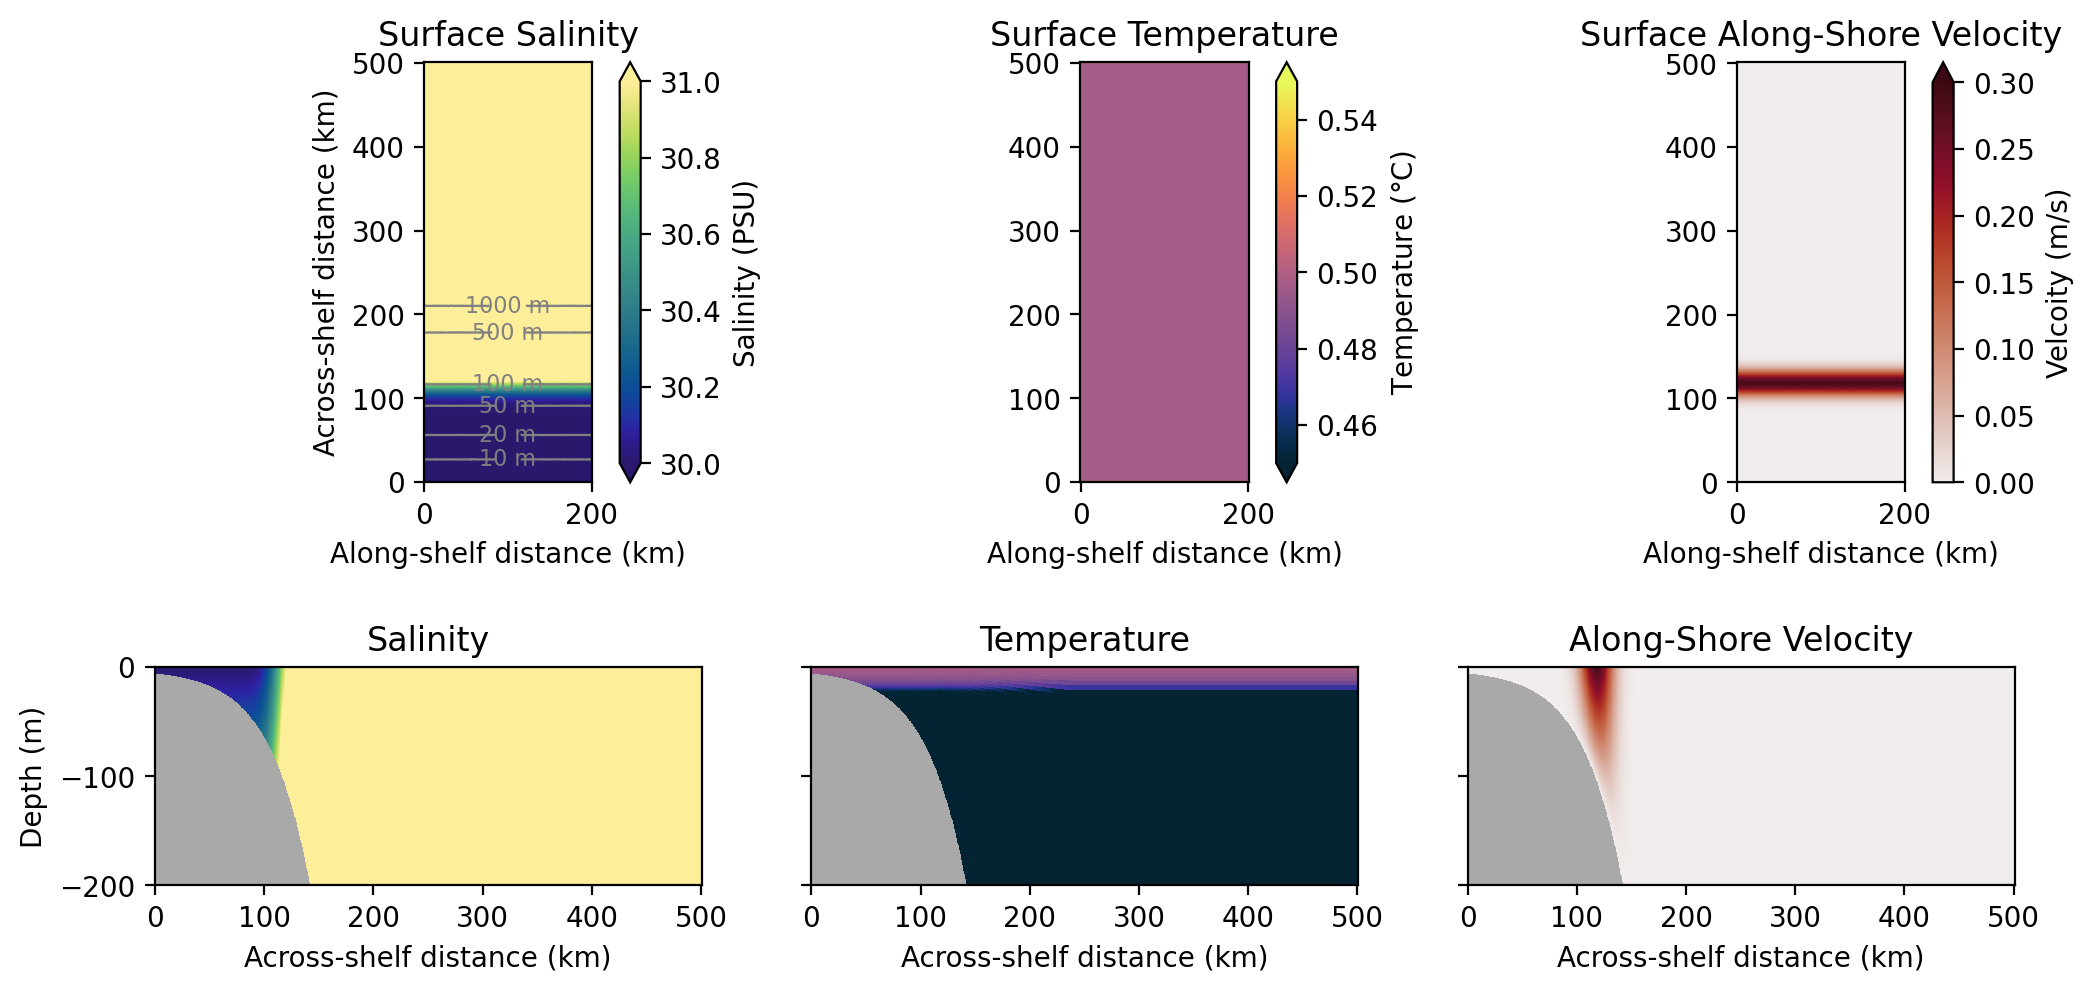

In [73]:
# Make a plot of surface and vertical things 

# Set the levels for things
lev_salt = np.arange(29,32,0.1)


# Make the figure
fig, ax = plt.subplots(2, 3, dpi=200, figsize=(12,6))

# Surface salinity
m1 = ax[0,0].pcolormesh(grid.x_rho/1000, grid.y_rho/1000, ini_conds.salt[-1,:,:], cmap=cmo.haline,
                        vmin=30, vmax=31)
fig.colorbar(m1, ax=ax[0,0], label='Salinity (PSU)', extend='both')
# Contours for bathymetry
positions = [(100, 10),(100,60),(100,90),(100,140),(100,160),(100,210)]
cs = ax[0,0].contour(grid.x_rho/1000, grid.y_rho/1000, grid.h, levels=[10, 20, 50, 100, 500, 1000],
                colors='gray', linewidths=0.8)
ax[0,0].clabel(cs, fmt='%d m', manual=positions, inline=True, fontsize=8, colors='gray')

# Surface temperature 
m2 = ax[0,1].pcolormesh(grid.x_rho/1000, grid.y_rho/1000, ini_conds.temp[-1,:,:], cmap=cmo.thermal,
                        vmin=0.45, vmax=0.55)
fig.colorbar(m2, ax=ax[0,1], label='Temperature ($\degree$C)', extend='both')

# Surface along-shore velocity 
m3 = ax[0,2].pcolormesh(grid.x_u/1000, grid.y_u/1000, ini_conds.u[0,-1,:,:], cmap=cmo.amp,
                        vmin=0, vmax=0.3)
fig.colorbar(m3, ax=ax[0,2], label='Velcoity (m/s)', extend='max')

# Set consistent axis limits
for r in range(3):
    ax[0,r].set_xlabel('Along-shelf distance (km)')
    ax[0,r].set_aspect(1)

# Vertical cross sections
# Salinity
m4 = ax[1,0].pcolormesh(grid.y_rho[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.salt[:,:,201], cmap=cmo.haline,
                        vmin=30, vmax=31)
#fig.colorbar(m4, ax=ax[1,0], label='(PSU)', extend='both')

# Temperature 
m5 = ax[1,1].pcolormesh(grid.y_rho[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.temp[:,:,201], cmap=cmo.thermal,
                        vmin=0.45, vmax=0.55)
#fig.colorbar(m5, ax=ax[1,1], label='($\degree$C)', extend='both')

# U
m6 = ax[1,2].pcolormesh(grid.y_u[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.u[0,:,:,201], cmap=cmo.amp,
                        vmin=0, vmax=0.3)
#fig.colorbar(m6, ax=ax[1,2], label='Velcoity (m/s)', extend='max')

for rr in range(3):
    # Set y lim
    ax[1,rr].set_ylim(-200,0)
    ax[1,rr].set_facecolor('darkgray')
    ax[1,rr].set_aspect(1.0)

# Label the axes
ax[0,0].set_ylabel('Across-shelf distance (km)')
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_xlabel('Across-shelf distance (km)')
ax[1,1].set_xlabel('Across-shelf distance (km)')
ax[1,2].set_xlabel('Across-shelf distance (km)')
ax[1,1].set_yticklabels('')
ax[1,2].set_yticklabels('')

# Give the subplots titles
ax[0,0].set_title('Surface Salinity')
ax[0,1].set_title('Surface Temperature')
ax[0,2].set_title('Surface Along-Shore Velocity')
ax[1,0].set_title('Salinity')
ax[1,1].set_title('Temperature')
ax[1,2].set_title('Along-Shore Velocity')

# fig.canvas.draw()

# for c in range(3):
#     top_pos = ax[0, c].get_position()
#     bottom_pos = ax[1, c].get_position()

#     top_center = top_pos.y0 + top_pos.height / 2
#     bottom_center = bottom_pos.y0 + bottom_pos.height / 2

#     dy = top_center - bottom_center

#     # Shift bottom axes by dy (relative move)
#     ax[1, c].set_position([
#         bottom_pos.x0,
#         bottom_pos.y0 + dy,
#         bottom_pos.width,
#         bottom_pos.height
#     ])


# 

In [ ]:

#

temp = ini_conds.temp[-1]
salt = ini_conds.salt[-1]
u = ini_conds.u[0,-1]

fig, ax = plt.subplots(1, 3, figsize=(9, 2.75),
                    constrained_layout=True, 
                    sharex=True, sharey=True, dpi=200)

# Temperature
m = ax[0].pcolormesh(xrho, yrho, temp, cmap=cmo.thermal)
fig.colorbar(m, ax=ax[0], label='[C]')

# Salinity
m1 = ax[1].pcolormesh(xrho, yrho, salt, cmap=cmo.haline)
fig.colorbar(m1, ax=ax[1], label='[g/kg]')

# U-velocity
m2 = ax[2].pcolormesh(xu, yu, u, cmap=cmo.amp)
fig.colorbar(m2, ax=ax[2], label='[m/s]')

# Set consistent axis limits
for a in ax:
    a.set_xlabel('Along-shelf distance [km]')
    a.set_aspect(1)

ax[0].set_ylabel('Across-shelf distance [km]')
ax[0].set_title('Surface temperature')
ax[1].set_title('Surface salinity')
ax[2].set_title('Surface alongshore velocity')

# Contours for bathymetry
positions = [(100, 10),(100,60),(100,90),(100,140),(100,160),(100,210)]
cs = ax[1].contour(xrho, yrho, dsg.h, levels=[10, 20, 50, 100, 500, 1000],
                colors='grey', linewidths=0.8)
ax[1].clabel(cs, fmt='%d m', manual=positions, inline=True, fontsize=8, colors='black')


print('Temperature min: ', ini_conds.temp.min().values)
print('Temperature max: ', ini_conds.temp.max().values)
print('Salinity min: ',   ini_conds.salt.min().values)
print('Salinity max: ',   ini_conds.salt.max().values)
print('U velocity min: ', ini_conds.u.min().values)
print('U velocity max: ', ini_conds.u.max().values)

# Plot cross section of initial conditions
tidx = 0

# Pick a fixed along-shelf location
xi_idx = 100  # pick a reasonable index along xi_rho

# --- Extract Data at the Final Time Step ---
temp_section = ini_conds.temp[:, :, xi_idx]        # shape: (s_rho, eta_rho)
salt_section = ini_conds.salt[:, :, xi_idx]        # shape: (s_rho, eta_rho)
z_rho_section = ini_conds.z_rho[tidx, :, :, xi_idx]       # shape: (s_rho, eta_rho)
u_section = ini_conds.u[tidx, :, :, xi_idx]  # shape: (s_rho, eta_u or eta_rho)

# --- Plotting 3x1 Subplots ---

# 1. Create the figure and a 3x1 grid of axes
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), sharex=True, 
                        sharey=True, dpi = 200, constrained_layout=True)

# 2. Define the horizontal coordinate (assuming it's y_rho for the across-shelf direction)
# Use dsg.y_rho for the coordinate.
y_coord = dgrid.y_rho[:, 0] / 1000  # Across-shelf distance in km

# Define common plotting parameters
common_ylim = (-200, 0)
xlabel = 'Across Shelf Distance [km]'

# --- Plot 1: Temperature ---
ax = axes[0]
pcm_temp = ax.pcolormesh(y_coord, z_rho_section, temp_section,
                        cmap='RdYlBu_r')
fig.colorbar(pcm_temp, ax=ax, label='Temperature [°C]')
# ax.set_title(f'Vertical Section at $\\xi={xi_idx}$')
ax.set_ylabel('Depth [m]')
ax.set_ylim(common_ylim)

# --- Plot 2: Salinity ---
ax = axes[1]
# Using typical values for demonstration:
pcm_salt = ax.pcolormesh(y_coord, z_rho_section, salt_section,
                        cmap=cmo.haline)
fig.colorbar(pcm_salt, ax=ax, label='Salinity [PSU]')
ax.set_ylim(common_ylim)

# --- Plot 3: U-Velocity ---
ax = axes[2]
# U-velocity is cross-shelf/along-shelf. Use vmin/vmax for flow speed.
# Assuming u is the along-shelf velocity and 0 is the interface:
pcm_u = ax.pcolormesh(y_coord, z_rho_section, u_section,
                    cmap=cmo.amp) # Example range
fig.colorbar(pcm_u, ax=ax, label='$u$ [m/s]')
ax.set_ylim(common_ylim)
ax.set_xlabel(xlabel) # Only set x-label on the bottom plot (shared x-axis)

for i in range(3):
    axes[i].set_facecolor('lightgray')
    axes[i].set_xlabel('Across-shelf distance [km]')
